In [4]:
!pip install pandas matplotlib openpyxl

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_excel('calenviroscreen40resultsdatadictionary_F_2021.xlsx')
print(df.shape)
df.head()

(8035, 58)


,Census Tract,Total Population,California County,ZIP,Approximate Location,Longitude,Latitude,CES 4.0 Score,CES 4.0 Percentile,CES 4.0 Percentile Range,...,Linguistic Isolation Pctl,Poverty,Poverty Pctl,Unemployment,Unemployment Pctl,Housing Burden,Housing Burden Pctl,Pop. Char.,Pop. Char. Score,Pop. Char. Pctl
0,6019001100,2780,Fresno,93706,Fresno,-119.781696,36.709695,93.183570,100.000000,95-100% (highest scores),...,79.374746,76.0,98.919598,12.8,93.831338,30.3,91.039290,93.155109,9.663213,99.722642
1,6077000700,4680,San Joaquin,95206,Stockton,-121.287873,37.943173,86.653790,99.987393,95-100% (highest scores),...,95.533902,73.2,98.391960,19.8,99.206143,31.2,92.281369,93.165408,9.664281,99.735250
2,6037204920,2751,Los Angeles,90023,Los Angeles,-118.197497,34.017500,82.393909,99.974786,95-100% (highest scores),...,81.553661,62.6,93.391960,6.4,61.530453,20.3,63.967047,83.751814,8.687785,95.789208
3,6019000700,3664,Fresno,93706,Fresno,-119.827707,36.734535,81.327940,99.962179,95-100% (highest scores),...,78.711598,65.7,95.351759,15.7,97.345133,35.4,96.413181,94.641227,9.817371,99.886536
4,6019000200,2689,Fresno,93706,Fresno,-119.805504,36.735491,80.745476,99.949571,95-100% (highest scores),...,86.561104,72.7,98.304020,13.7,95.288912,32.7,94.157161,95.398873,9.895964,99.949571


In [7]:
la = df[df['California County'].str.strip() == 'Los Angeles'].copy()
print(f"LA census tracts: {len(la)}")
la.head()

LA census tracts: 2343


,Census Tract,Total Population,California County,ZIP,Approximate Location,Longitude,Latitude,CES 4.0 Score,CES 4.0 Percentile,CES 4.0 Percentile Range,...,Linguistic Isolation Pctl,Poverty,Poverty Pctl,Unemployment,Unemployment Pctl,Housing Burden,Housing Burden Pctl,Pop. Char.,Pop. Char. Score,Pop. Char. Pctl
2,6037204920,2751,Los Angeles,90023,Los Angeles,-118.197497,34.017500,82.393909,99.974786,95-100% (highest scores),...,81.553661,62.6,93.391960,6.4,61.530453,20.3,63.967047,83.751814,8.687785,95.789208
5,6037542402,3306,Los Angeles,90221,Compton,-118.212413,33.881969,80.708813,99.936964,95-100% (highest scores),...,NaN,43.5,74.045226,9.3,83.224883,23.7,76.349810,83.366150,8.647779,95.461422
7,6037543202,5124,Los Angeles,90220,Compton,-118.230032,33.879862,79.290119,99.911750,95-100% (highest scores),...,60.617134,56.8,88.919598,12.6,93.492972,29.6,89.835234,85.436009,8.862491,96.898638
10,6037203300,2000,Los Angeles,90033,Los Angeles,-118.207788,34.058872,77.349097,99.873928,95-100% (highest scores),...,94.870754,71.7,97.952261,11.9,91.944300,28.3,87.490494,82.014461,8.507565,94.490671
11,6037291220,3640,Los Angeles,90247,Los Angeles,-118.286709,33.877139,77.253279,99.861321,95-100% (highest scores),...,86.750575,51.5,83.492462,4.5,37.714732,26.1,82.788340,74.473552,7.725328,86.006051


In [8]:
cols = ['Census Tract', 'Approximate Location', 'Longitude', 'Latitude',
        'PM2.5', 'Poverty', 'Asthma', 'CES 4.0 Score']
la_clean = la[cols].dropna()
print(f"After dropping NaN: {len(la_clean)}")
la_clean.head()

After dropping NaN: 2295


,Census Tract,Approximate Location,Longitude,Latitude,PM2.5,Poverty,Asthma,CES 4.0 Score
2,6037204920,Los Angeles,-118.197497,34.017500,12.251640,62.6,76.10,82.393909
5,6037542402,Compton,-118.212413,33.881969,12.252580,43.5,86.77,80.708813
7,6037543202,Compton,-118.230032,33.879862,12.216660,56.8,114.33,79.290119
10,6037203300,Los Angeles,-118.207788,34.058872,12.576875,71.7,65.53,77.349097
11,6037291220,Los Angeles,-118.286709,33.877139,12.066061,51.5,64.77,77.253279


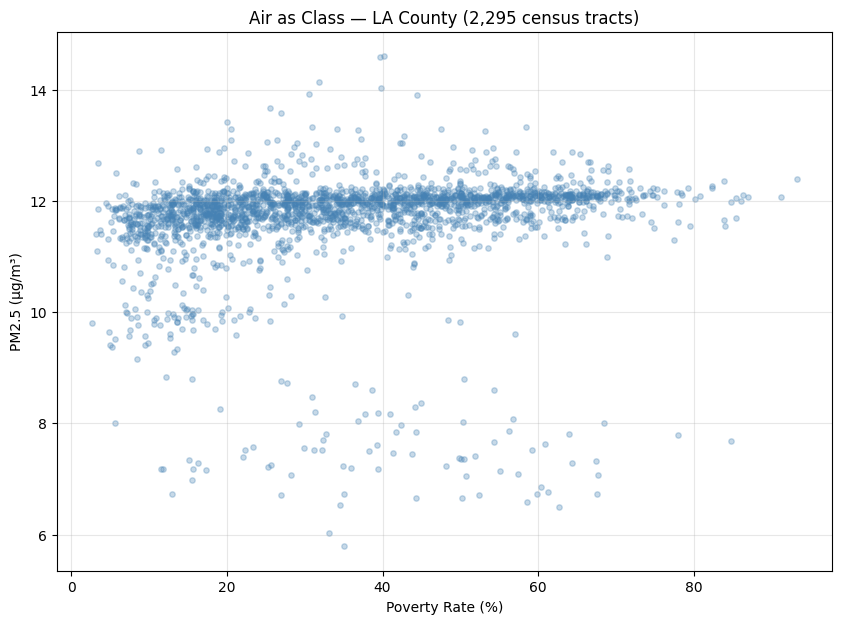

In [10]:
plt.figure(figsize=(10, 7))
plt.scatter(la_clean['Poverty'], la_clean['PM2.5'], 
            alpha=0.3, s=15, c='steelblue')
plt.xlabel('Poverty Rate (%)')
plt.ylabel('PM2.5 (μg/m³)')
plt.title('Air as Class — LA County (2,295 census tracts)')
plt.grid(alpha=0.3)
plt.savefig('air_as_class_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1100x700 with 0 Axes>

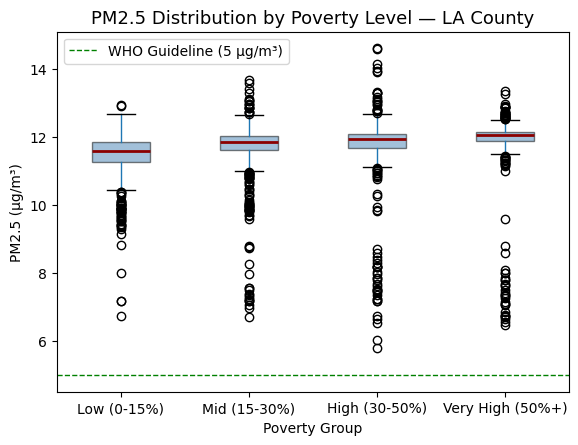

In [13]:
la_clean['Poverty Group'] = pd.cut(
    la_clean['Poverty'],
    bins=[0, 15, 30, 50, 100],
    labels=['Low (0-15%)', 'Mid (15-30%)', 'High (30-50%)', 'Very High (50%+)']
)

plt.figure(figsize=(11, 7))
la_clean.boxplot(column='PM2.5', by='Poverty Group', 
                 grid=False, patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.5),
                 medianprops=dict(color='darkred', linewidth=2))

plt.suptitle('')
plt.title('PM2.5 Distribution by Poverty Level — LA County', fontsize=13)
plt.xlabel('Poverty Group')
plt.ylabel('PM2.5 (μg/m³)')
plt.axhline(y=5, color='green', linestyle='--', linewidth=1, label='WHO Guideline (5 μg/m³)')
plt.legend()
plt.savefig('air_as_class_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
choice = la_clean.groupby('Poverty Group', observed=True).apply(
    lambda g: (g['PM2.5'] < 10).mean() * 100
)

print("Clean Air Choice Rate (% tracts with PM2.5 < 10):")
print(choice.round(1))

Clean Air Choice Rate (% tracts with PM2.5 < 10):
Poverty Group
Low (0-15%)         11.0
Mid (15-30%)         5.0
High (30-50%)        4.8
Very High (50%+)     5.4
dtype: float64


In [15]:
print("Group sizes:")
print(la_clean['Poverty Group'].value_counts())
print()
print("Very High poverty + PM2.5 < 10:")
very_high_clean = la_clean[
    (la_clean['Poverty Group'] == 'Very High (50%+)') & 
    (la_clean['PM2.5'] < 10)
]
print(very_high_clean[['Approximate Location', 'PM2.5', 'Poverty']].head(20))

Group sizes:
Poverty Group
High (30-50%)       706
Mid (15-30%)        694
Very High (50%+)    551
Low (0-15%)         344
Name: count, dtype: int64

Very High poverty + PM2.5 < 10:
                        Approximate Location     PM2.5  Poverty
851   Unincorporated Los Angeles County area  6.708035     52.4
887                                Lancaster  6.736203     67.5
907                                Lancaster  7.620827     60.9
933   Unincorporated Los Angeles County area  6.858854     60.3
1087                               Lancaster  7.089535     57.4
1122                               Lancaster  7.320472     67.4
1244                               Lancaster  7.359970     50.1
1402                               Lancaster  7.282015     64.3
1575                               Lancaster  7.079347     67.7
1606  Unincorporated Los Angeles County area  8.016552     50.4
1614                                Palmdale  8.006411     68.5
1714                                Palmdale  7.68

In [16]:
# Tag outer vs inner LA based on location name
outer_keywords = ['Lancaster', 'Palmdale', 'Santa Clarita', 'Unincorporated', 
                   'Acton', 'Agua Dulce', 'Castaic', 'Quartz Hill']

la_clean['Area Type'] = la_clean['Approximate Location'].apply(
    lambda x: 'Outer LA' if any(k in str(x) for k in outer_keywords) else 'Inner LA'
)

print(la_clean['Area Type'].value_counts())

Area Type
Inner LA    2138
Outer LA     157
Name: count, dtype: int64


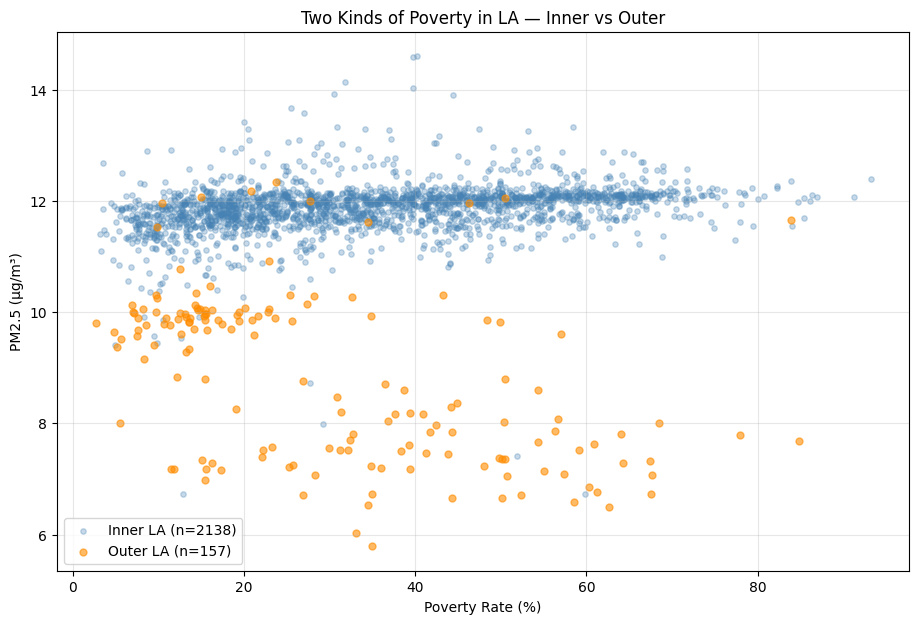

In [17]:
plt.figure(figsize=(11, 7))

inner = la_clean[la_clean['Area Type'] == 'Inner LA']
outer = la_clean[la_clean['Area Type'] == 'Outer LA']

plt.scatter(inner['Poverty'], inner['PM2.5'], 
            alpha=0.3, s=15, c='steelblue', label='Inner LA (n=2138)')
plt.scatter(outer['Poverty'], outer['PM2.5'], 
            alpha=0.6, s=25, c='darkorange', label='Outer LA (n=157)')

plt.xlabel('Poverty Rate (%)')
plt.ylabel('PM2.5 (μg/m³)')
plt.title('Two Kinds of Poverty in LA — Inner vs Outer')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.savefig('air_as_class_two_kinds.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
!pip install folium


   ---------------------------------------- 0/3 [xyzservices]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   ---------------------------------------- 3/3 [folium]



In [19]:
import folium

m = folium.Map(location=[34.05, -118.25], zoom_start=9, tiles='CartoDB positron')

# Inner LA = blue, Outer LA = orange
for _, row in la_clean.iterrows():
    color = 'steelblue' if row['Area Type'] == 'Inner LA' else 'darkorange'
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color=color,
        fill=True,
        fill_opacity=0.5,
        weight=0
    ).add_to(m)

m.save('air_as_class_map.html')
m

In [20]:
print("Asthma stats (LA):")
print(la_clean['Asthma'].describe().round(1))
print()
print("Asthma by Area Type:")
print(la_clean.groupby('Area Type')['Asthma'].describe().round(1))

Asthma stats (LA):
count    2295.0
mean       54.2
std        28.2
min         5.9
25%        32.8
50%        50.3
75%        69.5
max       158.0
Name: Asthma, dtype: float64

Asthma by Area Type:
            count  mean   std  min   25%   50%   75%    max
Area Type                                                  
Inner LA   2138.0  53.5  26.4  8.4  33.2  50.2  68.9  147.6
Outer LA    157.0  64.1  45.4  5.9  29.0  51.5  90.4  158.0


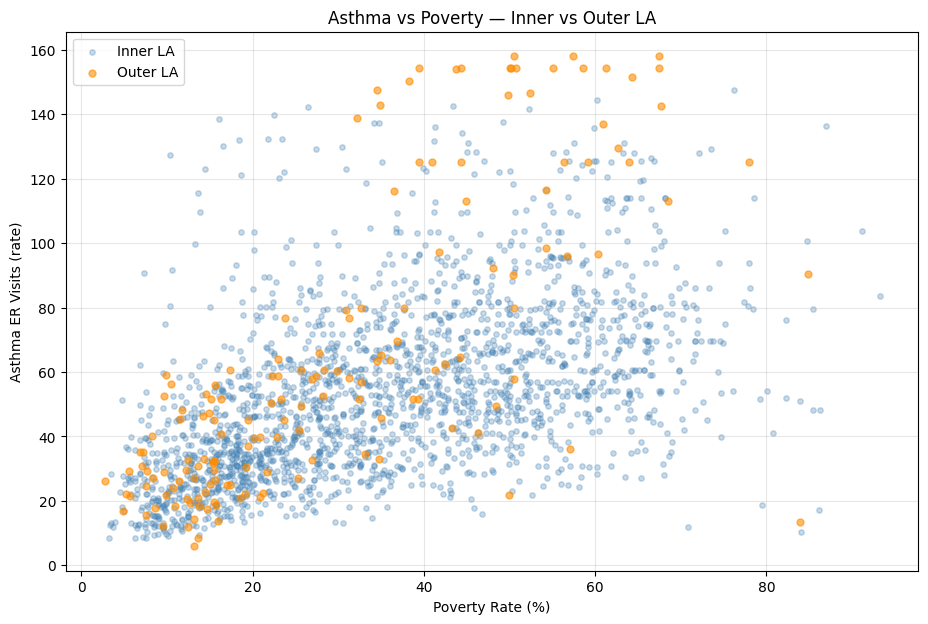

In [21]:
# Plot Asthma by Area Type
plt.figure(figsize=(11, 7))

inner = la_clean[la_clean['Area Type'] == 'Inner LA']
outer = la_clean[la_clean['Area Type'] == 'Outer LA']

plt.scatter(inner['Poverty'], inner['Asthma'], 
            alpha=0.3, s=15, c='steelblue', label='Inner LA')
plt.scatter(outer['Poverty'], outer['Asthma'], 
            alpha=0.6, s=25, c='darkorange', label='Outer LA')

plt.xlabel('Poverty Rate (%)')
plt.ylabel('Asthma ER Visits (rate)')
plt.title('Asthma vs Poverty — Inner vs Outer LA')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.savefig('air_as_class_asthma.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
print("Correlation: Poverty vs Asthma")
print(f"  Overall: {la_clean['Poverty'].corr(la_clean['Asthma']):.3f}")
print(f"  Inner LA: {inner['Poverty'].corr(inner['Asthma']):.3f}")
print(f"  Outer LA: {outer['Poverty'].corr(outer['Asthma']):.3f}")
print()
print("Correlation: PM2.5 vs Asthma")
print(f"  Overall: {la_clean['PM2.5'].corr(la_clean['Asthma']):.3f}")
print(f"  Inner LA: {inner['PM2.5'].corr(inner['Asthma']):.3f}")
print(f"  Outer LA: {outer['PM2.5'].corr(outer['Asthma']):.3f}")

Correlation: Poverty vs Asthma
  Overall: 0.526
  Inner LA: 0.519
  Outer LA: 0.744

Correlation: PM2.5 vs Asthma
  Overall: -0.097
  Inner LA: 0.204
  Outer LA: -0.628


In [23]:
poor_outer = la_clean[
    (la_clean['Area Type'] == 'Outer LA') & 
    (la_clean['Poverty'] > 50)
].copy()

print(f"Poor Outer LA tracts: {len(poor_outer)}")
print()
print("Locations:")
print(poor_outer['Approximate Location'].value_counts())

Poor Outer LA tracts: 30

Locations:
Approximate Location
Lancaster                                 13
Palmdale                                  10
Unincorporated Los Angeles County area     6
Santa Clarita                              1
Name: count, dtype: int64


In [25]:
cols = ['PM2.5', 'Diesel PM', 'Traffic', 'Poverty', 'Unemployment', 
        'Education', 'Asthma', 'Cardiovascular Disease', 'Housing Burden']

# Tag Area Type on full la dataframe
outer_keywords = ['Lancaster', 'Palmdale', 'Santa Clarita', 'Unincorporated', 
                   'Acton', 'Agua Dulce', 'Castaic', 'Quartz Hill']
la['Area Type'] = la['Approximate Location'].apply(
    lambda x: 'Outer LA' if any(k in str(x) for k in outer_keywords) else 'Inner LA'
)

# Three groups
poor_outer = la[(la['Area Type'] == 'Outer LA') & (la['Poverty'] > 50)]
poor_inner = la[(la['Area Type'] == 'Inner LA') & (la['Poverty'] > 50)]
rich_inner = la[(la['Area Type'] == 'Inner LA') & (la['Poverty'] < 15)]

profile = pd.DataFrame({
    f'Poor Outer (n={len(poor_outer)})': poor_outer[cols].mean(),
    f'Poor Inner (n={len(poor_inner)})': poor_inner[cols].mean(),
    f'Rich Inner (n={len(rich_inner)})': rich_inner[cols].mean()
})

print(profile.round(2))

                        Poor Outer (n=30)  Poor Inner (n=525)  \
PM2.5                                7.77               12.02   
Diesel PM                            0.11                0.41   
Traffic                            800.12             1431.61   
Poverty                             60.18               60.75   
Unemployment                        10.22                8.12   
Education                           29.65               41.67   
Asthma                             121.73               70.38   
Cardiovascular Disease              20.42               17.08   
Housing Burden                      25.19               31.47   

                        Rich Inner (n=300)  
PM2.5                                11.57  
Diesel PM                             0.15  
Traffic                            1296.28  
Poverty                              10.40  
Unemployment                          4.54  
Education                             4.37  
Asthma                            

In [26]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.5 MB 8.4 MB/s eta 0:00:01
   ----------------- ---------------------- 4.2/9.5 MB 10.9 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.5 MB 12.1 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 12.8 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 10.6 MB/s  0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   -- ------------------------------------- 2.6/36.5 MB 13.7 MB/s eta 0:00:03
   ----- ---------------------------------- 5.2/36.5 MB 13.8 MB/s eta 0:00:03
   -------- ------------------------------- 7.9/36.5 MB 12.8 MB/s eta 0:00:03
   ----------- ---------------------------- 10.5/36.5 MB 12.8 MB/s eta 0:00:03
   -------------- ------------------------- 13.6/36.5 MB 13.2 MB/s eta 0:00:02
   ------------------ --------------------- 17.3/36.5 MB 13.8 MB/s eta 0:00:02
   ------

In [27]:
import statsmodels.api as sm

# Drop rows with NaN in any of the variables we need
reg_data = la[['Asthma', 'PM2.5', 'Poverty']].dropna()

# Standardize variables so coefficients are comparable
reg_data_std = (reg_data - reg_data.mean()) / reg_data.std()

# Multiple regression: Asthma ~ PM2.5 + Poverty
X = reg_data_std[['PM2.5', 'Poverty']]
X = sm.add_constant(X)
y = reg_data_std['Asthma']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Asthma   R-squared:                       0.298
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     488.8
Date:                Tue, 12 May 2026   Prob (F-statistic):          1.15e-177
Time:                        15:40:07   Log-Likelihood:                -2862.2
No. Observations:                2305   AIC:                             5730.
Df Residuals:                    2302   BIC:                             5748.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.927e-16      0.017    3.4e-14      1.0

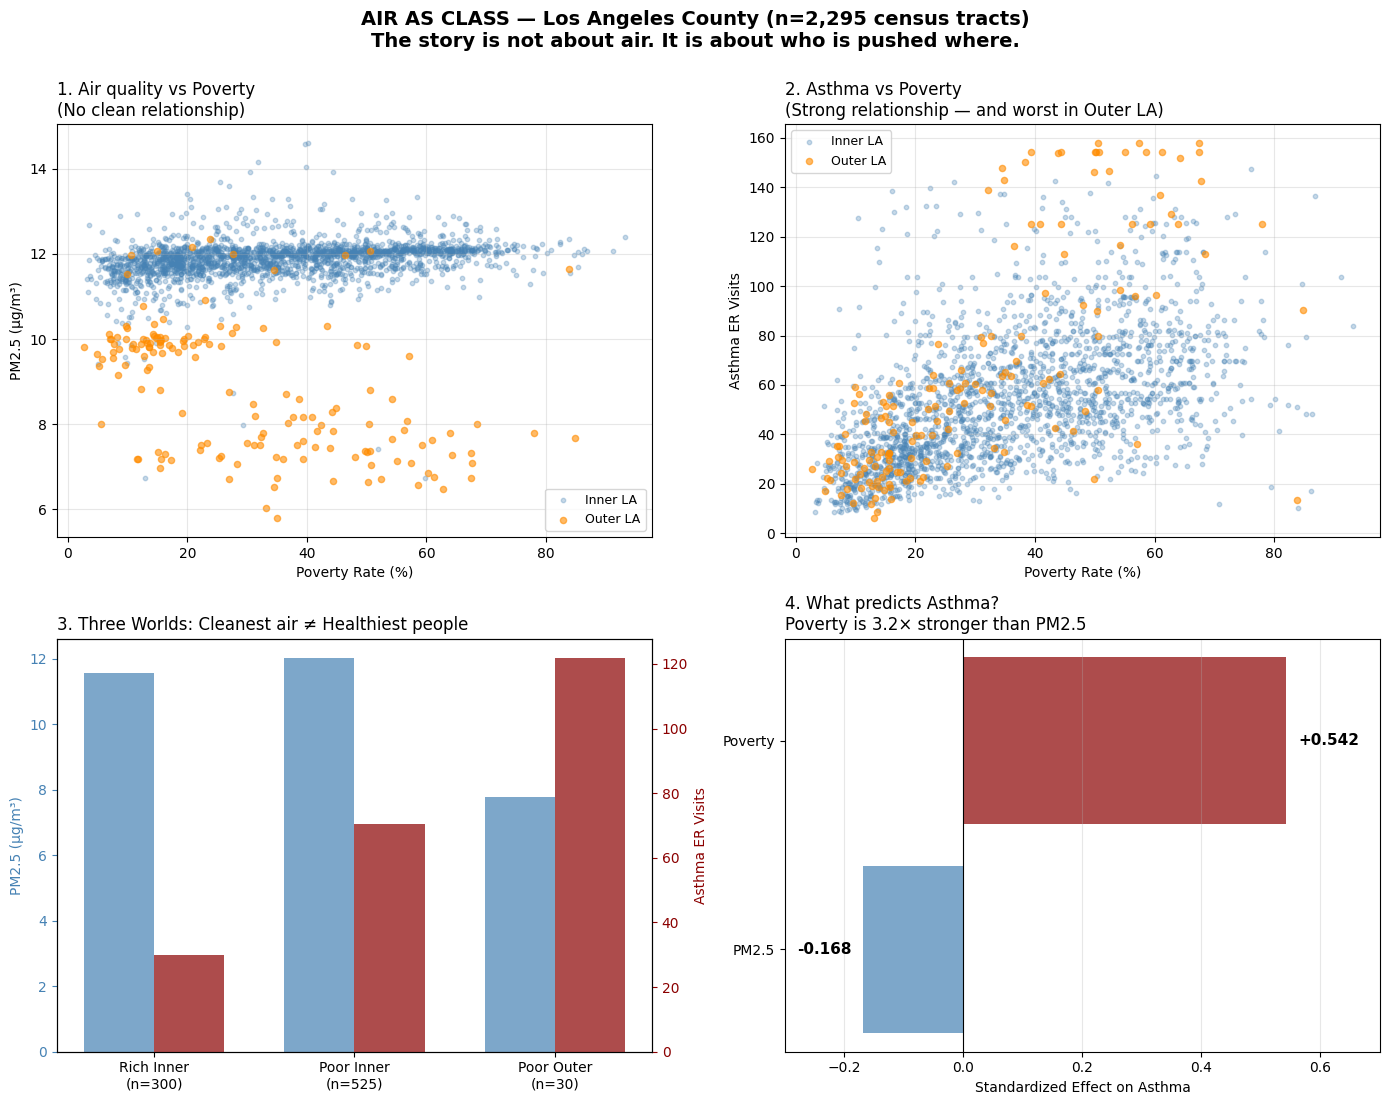

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

inner = la_clean[la_clean['Area Type'] == 'Inner LA']
outer = la_clean[la_clean['Area Type'] == 'Outer LA']

# Panel 1
ax = axes[0, 0]
ax.scatter(inner['Poverty'], inner['PM2.5'], alpha=0.3, s=10, c='steelblue', label='Inner LA')
ax.scatter(outer['Poverty'], outer['PM2.5'], alpha=0.6, s=20, c='darkorange', label='Outer LA')
ax.set_xlabel('Poverty Rate (%)')
ax.set_ylabel('PM2.5 (μg/m³)')
ax.set_title('1. Air quality vs Poverty\n(No clean relationship)', fontsize=12, loc='left')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# Panel 2
ax = axes[0, 1]
ax.scatter(inner['Poverty'], inner['Asthma'], alpha=0.3, s=10, c='steelblue', label='Inner LA')
ax.scatter(outer['Poverty'], outer['Asthma'], alpha=0.6, s=20, c='darkorange', label='Outer LA')
ax.set_xlabel('Poverty Rate (%)')
ax.set_ylabel('Asthma ER Visits')
ax.set_title('2. Asthma vs Poverty\n(Strong relationship — and worst in Outer LA)', fontsize=12, loc='left')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

# Panel 3
ax = axes[1, 0]
groups = ['Rich Inner\n(n=300)', 'Poor Inner\n(n=525)', 'Poor Outer\n(n=30)']
pm25_vals = [11.57, 12.02, 7.77]
asthma_vals = [29.94, 70.38, 121.73]

x = range(len(groups))
width = 0.35
ax2 = ax.twinx()
ax.bar([i - width/2 for i in x], pm25_vals, width, color='steelblue', alpha=0.7, label='PM2.5')
ax2.bar([i + width/2 for i in x], asthma_vals, width, color='darkred', alpha=0.7, label='Asthma')
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel('PM2.5 (μg/m³)', color='steelblue')
ax2.set_ylabel('Asthma ER Visits', color='darkred')
ax.set_title('3. Three Worlds: Cleanest air ≠ Healthiest people', fontsize=12, loc='left')
ax.tick_params(axis='y', colors='steelblue')
ax2.tick_params(axis='y', colors='darkred')

# Panel 4 — fixed
ax = axes[1, 1]
variables = ['PM2.5', 'Poverty']
coefs = [-0.168, 0.542]
colors = ['steelblue', 'darkred']
bars = ax.barh(variables, coefs, color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized Effect on Asthma')
ax.set_title('4. What predicts Asthma?\nPoverty is 3.2× stronger than PM2.5', fontsize=12, loc='left')
ax.grid(alpha=0.3, axis='x')
ax.set_xlim(-0.3, 0.7)  # extra space for labels

# Place labels outside bars
for bar, val in zip(bars, coefs):
    if val > 0:
        ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                f'+{val:.3f}', va='center', ha='left', fontsize=11, fontweight='bold')
    else:
        ax.text(val - 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha='right', fontsize=11, fontweight='bold')

fig.suptitle('AIR AS CLASS — Los Angeles County (n=2,295 census tracts)\n' + 
             'The story is not about air. It is about who is pushed where.',
             fontsize=14, fontweight='bold', y=1.00)

plt.tight_layout()
plt.savefig('air_as_class_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Export key data for Datawrapper
export = la_clean[['Approximate Location', 'Poverty', 'PM2.5', 'Asthma', 'Area Type']].copy()
export.to_csv('air_as_class_data.csv', index=False)
print(f"Saved {len(export)} rows to air_as_class_data.csv")

Saved 2295 rows to air_as_class_data.csv


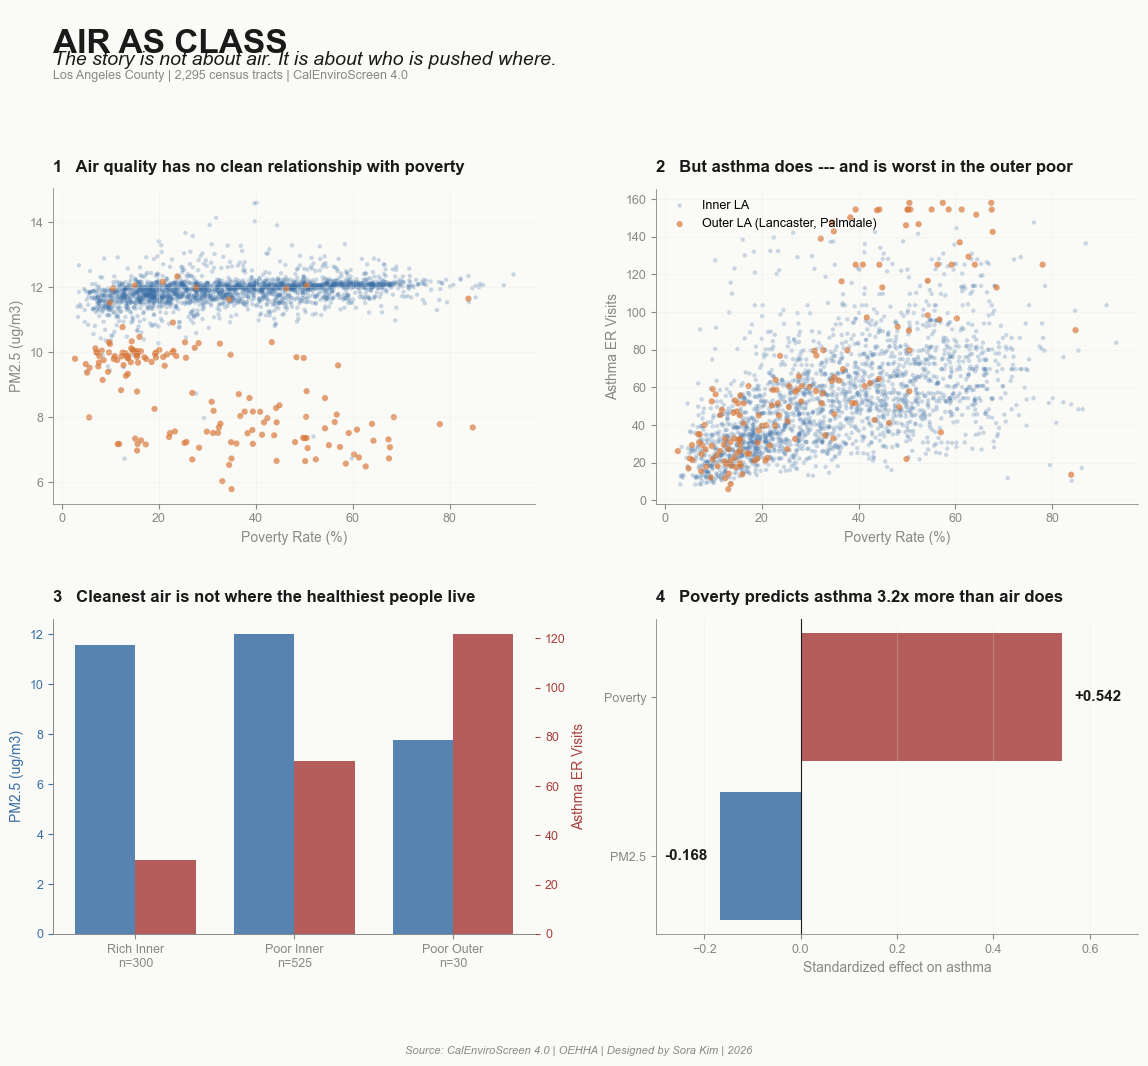

In [32]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# === Design tokens ===
COLOR_BG       = "#FAFAF7"
COLOR_FG       = "#1A1A1A"
COLOR_MUTED    = "#888888"
COLOR_GRID     = "#E5E5E0"
COLOR_INNER    = "#3A6EA5"
COLOR_OUTER    = "#D97A3C"
COLOR_RED      = "#A8423E"

# === Apply global style ===
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "normal",
    "axes.labelsize": 10,
    "axes.labelcolor": COLOR_MUTED,
    "axes.edgecolor": COLOR_MUTED,
    "axes.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.facecolor": COLOR_BG,
    "axes.facecolor": COLOR_BG,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.5,
    "legend.frameon": False,
    "legend.fontsize": 9,
})

inner = la_clean[la_clean["Area Type"] == "Inner LA"]
outer = la_clean[la_clean["Area Type"] == "Outer LA"]

fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[0.4, 2, 2], hspace=0.5, wspace=0.25)

# === Header ===
ax_header = fig.add_subplot(gs[0, :])
ax_header.axis("off")
ax_header.text(0, 0.7, "AIR AS CLASS",
               fontsize=24, fontweight="bold", color=COLOR_FG,
               transform=ax_header.transAxes, va="top")
ax_header.text(0, 0.35, "The story is not about air. It is about who is pushed where.",
               fontsize=14, color=COLOR_FG, style="italic",
               transform=ax_header.transAxes, va="top")
ax_header.text(0, 0.05, "Los Angeles County | 2,295 census tracts | CalEnviroScreen 4.0",
               fontsize=9, color=COLOR_MUTED,
               transform=ax_header.transAxes, va="top")

# === Panel 1 ===
ax1 = fig.add_subplot(gs[1, 0])
ax1.scatter(inner["Poverty"], inner["PM2.5"], alpha=0.25, s=10, c=COLOR_INNER, edgecolors="none")
ax1.scatter(outer["Poverty"], outer["PM2.5"], alpha=0.7, s=20, c=COLOR_OUTER, edgecolors="none")
ax1.set_xlabel("Poverty Rate (%)")
ax1.set_ylabel("PM2.5 (ug/m3)")
ax1.set_title("1   Air quality has no clean relationship with poverty",
              loc="left", fontweight="bold", color=COLOR_FG, pad=12)
ax1.grid(True, alpha=0.4)

# === Panel 2 ===
ax2 = fig.add_subplot(gs[1, 1])
ax2.scatter(inner["Poverty"], inner["Asthma"], alpha=0.25, s=10, c=COLOR_INNER,
            edgecolors="none", label="Inner LA")
ax2.scatter(outer["Poverty"], outer["Asthma"], alpha=0.7, s=20, c=COLOR_OUTER,
            edgecolors="none", label="Outer LA (Lancaster, Palmdale)")
ax2.set_xlabel("Poverty Rate (%)")
ax2.set_ylabel("Asthma ER Visits")
ax2.set_title("2   But asthma does --- and is worst in the outer poor",
              loc="left", fontweight="bold", color=COLOR_FG, pad=12)
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.4)

# === Panel 3 ===
ax3 = fig.add_subplot(gs[2, 0])
groups = ["Rich Inner", "Poor Inner", "Poor Outer"]
pm25_vals = [11.57, 12.02, 7.77]
asthma_vals = [29.94, 70.38, 121.73]
counts = [300, 525, 30]

x = range(len(groups))
width = 0.38
ax3_2 = ax3.twinx()
ax3.bar([i - width/2 for i in x], pm25_vals, width, color=COLOR_INNER, alpha=0.85, label="PM2.5")
ax3_2.bar([i + width/2 for i in x], asthma_vals, width, color=COLOR_RED, alpha=0.85, label="Asthma")

ax3.set_xticks(x)
ax3.set_xticklabels([f"{g}\nn={c}" for g, c in zip(groups, counts)])
ax3.set_ylabel("PM2.5 (ug/m3)", color=COLOR_INNER)
ax3_2.set_ylabel("Asthma ER Visits", color=COLOR_RED)
ax3.tick_params(axis="y", colors=COLOR_INNER)
ax3_2.tick_params(axis="y", colors=COLOR_RED)
ax3_2.spines["top"].set_visible(False)
ax3.set_title("3   Cleanest air is not where the healthiest people live",
              loc="left", fontweight="bold", color=COLOR_FG, pad=12)

# === Panel 4 ===
ax4 = fig.add_subplot(gs[2, 1])
variables = ["PM2.5", "Poverty"]
coefs = [-0.168, 0.542]
colors_bar = [COLOR_INNER, COLOR_RED]
bars = ax4.barh(variables, coefs, color=colors_bar, alpha=0.85)
ax4.axvline(x=0, color=COLOR_FG, linewidth=0.8)
ax4.set_xlabel("Standardized effect on asthma")
ax4.set_title("4   Poverty predicts asthma 3.2x more than air does",
              loc="left", fontweight="bold", color=COLOR_FG, pad=12)
ax4.grid(True, alpha=0.4, axis="x")
ax4.set_xlim(-0.3, 0.7)

for bar, val in zip(bars, coefs):
    if val > 0:
        ax4.text(val + 0.025, bar.get_y() + bar.get_height()/2,
                f"+{val:.3f}", va="center", ha="left", fontsize=11, fontweight="bold", color=COLOR_FG)
    else:
        ax4.text(val - 0.025, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", ha="right", fontsize=11, fontweight="bold", color=COLOR_FG)

# === Footer ===
fig.text(0.5, 0.01, "Source: CalEnviroScreen 4.0 | OEHHA | Designed by Sora Kim | 2026",
         ha="center", fontsize=8, color=COLOR_MUTED, style="italic")

plt.savefig("air_as_class_summary_v2.png", dpi=200, bbox_inches="tight", facecolor=COLOR_BG)
plt.show()